In [ ]:
import torch
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))
else: print('No GPU — switch Runtime to T4 GPU')

CUDA: True
GPU: Tesla T4


In [ ]:
!pip install transformers==4.40.0 -q

In [ ]:
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print(f'Loaded: {DATA_PATH}')

Saving NEW DATASET-2_30.csv to NEW DATASET-2_30.csv
Loaded: NEW DATASET-2_30.csv


In [ ]:
import os, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)
from transformers import (
    DistilBertTokenizerFast, DistilBertModel,
    AdamW, get_linear_schedule_with_warmup,
)

CONFIG = {
    'model_name'     : 'distilbert-base-uncased',
    'max_length'     : 128,
    'batch_size'     : 16,
    'num_epochs'     : 6,
    'patience'       : 2,
    'lr_backbone'    : 1e-5,
    'lr_heads'       : 2e-5,
    'warmup_ratio'   : 0.1,
    'stage1_weight'  : 1.5,
    'stage2_weight'  : 2.0,
    'dropout'        : 0.5,
    'label_smoothing': 0.15,
    'test_size'      : 0.15,
    'val_size'       : 0.15,
    'seed'           : 42,
    'save_dir'       : '/content/saved_twostage',
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
}

# Stage 1 labels
S1_LABEL2ID = {'ham': 0, 'phishing': 1}
S1_ID2LABEL = {0: 'ham', 1: 'phishing'}

# Stage 2 labels (attack type)
S2_LABEL2ID = {'phone_phishing': 0, 'url_phishing': 1, 'email_phishing': 2}
S2_ID2LABEL = {v: k for k, v in S2_LABEL2ID.items()}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
print(f"Device: {CONFIG['device']}")


Device: cuda


In [ ]:
def load_data(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['LABEL'] = df['LABEL'].str.strip().str.lower()
    df['TEXT']  = df['TEXT'].fillna('').astype(str).str.strip()
    for col in ['URL', 'EMAIL', 'PHONE']:
        df[col] = (df[col].str.strip().str.lower() == 'yes').astype(int)
    df['flag_sum'] = df['URL'] + df['EMAIL'] + df['PHONE']
    def get_labels(row):
        s1 = 0 if row['LABEL'] == 'ham' else 1
        s2 = -1
        if s1 == 1:
          if row['flag_sum'] == 1:
            if row['PHONE'] == 1: s2 = S2_LABEL2ID['phone_phishing']
            elif row['URL'] == 1: s2 = S2_LABEL2ID['url_phishing']
            elif row['EMAIL']== 1: s2 = S2_LABEL2ID['email_phishing']
          elif row['flag_sum'] > 1:
            if row['PHONE'] == 1: s2 = S2_LABEL2ID['phone_phishing']
            elif row['URL'] == 1: s2 = S2_LABEL2ID['url_phishing']
            else: s2 = S2_LABEL2ID['email_phishing']
        return pd.Series({'s1_label': s1, 's2_label': s2})
    df[['s1_label', 's2_label']] = df.apply(get_labels, axis=1)
    print('\n Dataset Summary')
    print(f'  Total rows              : {len(df)}')
    print(f'  Stage 1 — ham           : {(df.s1_label==0).sum()}')
    print(f'  Stage 1 — phishing      : {(df.s1_label==1).sum()}')
    s2 = df[df.s2_label >= 0]
    print(f'  Stage 2 — phone_phishing: {(s2.s2_label==0).sum()}')
    print(f'  Stage 2 — url_phishing  : {(s2.s2_label==1).sum()}')
    print(f'  Stage 2 — email_phishing: {(s2.s2_label==2).sum()}')
    print(f'  Stage 2 — no label (ham/ambiguous): {(df.s2_label==-1).sum()}')
    return df
df = load_data(DATA_PATH)
df[['LABEL','TEXT','s1_label','s2_label']].head(6)


 Dataset Summary
  Total rows              : 9344
  Stage 1 — ham           : 3393
  Stage 1 — phishing      : 5951
  Stage 2 — phone_phishing: 2711
  Stage 2 — url_phishing  : 1271
  Stage 2 — email_phishing: 366
  Stage 2 — no label (ham/ambiguous): 4996


,LABEL,TEXT,s1_label,s2_label
0,smishing,CommBank: A transaction was performed using yo...,1,2
1,smishing,CommB: A transaction was performed using your ...,1,2
2,smishing,CommB: A transaction was performed using your ...,1,2
3,smishing,"Delivered: Hi Mohammed Farhan, your package wi...",1,1
4,smishing,A Unknown Transaction Has Been Made With Your ...,1,2
5,smishing,notification-order@pack.com / notice / U S P S...,1,2


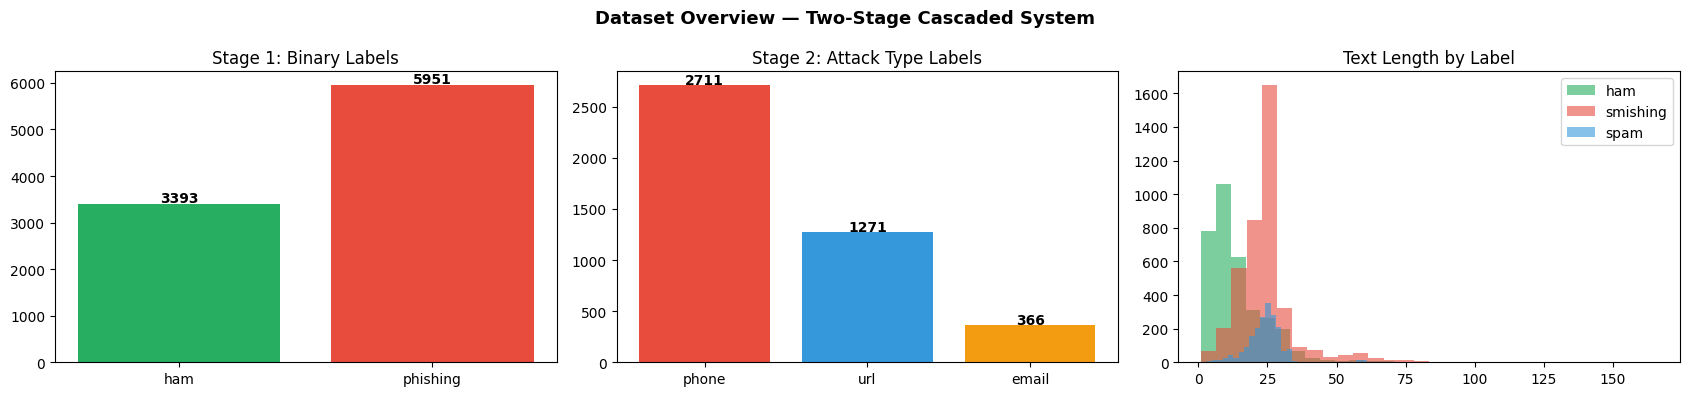

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
# Stage 1 distribution
s1_counts = df['s1_label'].value_counts().sort_index()
axes[0].bar(['ham','phishing'], s1_counts.values, color=['#27AE60','#E74C3C'])
axes[0].set_title('Stage 1: Binary Labels', fontsize=12)
for i,v in enumerate(s1_counts.values): axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')
# Stage 2 distribution
s2 = df[df.s2_label >= 0].copy()
s2_counts = s2['s2_label'].value_counts().sort_index()
axes[1].bar(['phone','url','email'], s2_counts.values, color=['#E74C3C','#3498DB','#F39C12'])
axes[1].set_title('Stage 2: Attack Type Labels', fontsize=12)
for i,v in enumerate(s2_counts.values): axes[1].text(i, v+10, str(v), ha='center', fontweight='bold')
# Text length
df['wc'] = df['TEXT'].str.split().str.len()
for lbl, col in [('ham','#27AE60'),('smishing','#E74C3C'),('spam','#3498DB')]:
    sub = df[df['LABEL']==lbl]['wc']
    if len(sub): axes[2].hist(sub, bins=30, alpha=0.6, label=lbl, color=col)
axes[2].set_title('Text Length by Label', fontsize=12)
axes[2].legend()
plt.suptitle('Dataset Overview — Two-Stage Cascaded System', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=CONFIG['test_size']+CONFIG['val_size'],
    stratify=df['s1_label'], random_state=CONFIG['seed']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.2,
    stratify=temp_df['s1_label'], random_state=CONFIG['seed']
)
print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')
for name, d in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    print(f'  {name}: ham={( d.s1_label==0).sum()}  phishing={(d.s1_label==1).sum()}  '
          f'[s2: phone={(d.s2_label==0).sum()} url={(d.s2_label==1).sum()} email={(d.s2_label==2).sum()}]')

Train: 6,540  |  Val: 2,243  |  Test: 561
  Train: ham=2375  phishing=4165  [s2: phone=1898 url=881 email=264]
  Val: ham=814  phishing=1429  [s2: phone=636 url=319 email=81]
  Test: ham=204  phishing=357  [s2: phone=177 url=71 email=21]


In [ ]:
# Stage 1 weights
s1_counts  = Counter(train_df['s1_label'].tolist())
s1_total   = sum(s1_counts.values())
s1_weights = torch.tensor(
    [s1_total/(2*s1_counts[i]) for i in range(2)], dtype=torch.float
).to(CONFIG['device'])

# Stage 2 weights (phishing-only rows)
s2_rows   = train_df[train_df.s2_label >= 0]
s2_counts = Counter(s2_rows['s2_label'].tolist())
s2_total  = sum(s2_counts.values())
s2_weights = torch.tensor(
    [s2_total/(3*s2_counts[i]) for i in range(3)], dtype=torch.float
).to(CONFIG['device'])

print(f'Stage 1 class weights: { {S1_ID2LABEL[i]: round(float(s1_weights[i]),3) for i in range(2)} }')
print(f'Stage 2 class weights: { {S2_ID2LABEL[i]: round(float(s2_weights[i]),3) for i in range(3)} }')

# Weighted sampler for training
sw = [1.0/s1_counts[l] for l in train_df['s1_label'].tolist()]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

Stage 1 class weights: {'ham': 1.377, 'phishing': 0.785}
Stage 2 class weights: {'phone_phishing': 0.534, 'url_phishing': 1.151, 'email_phishing': 3.842}


In [ ]:
class CascadeSMSDataset(Dataset):
    #Returns input_ids, attention_mask, s1_label, s2_label for each SMS.
    def __init__(self, df, tokenizer, max_len, augment=False):
        self.texts     = df['TEXT'].tolist()
        self.s1_labels = df['s1_label'].tolist()
        self.s2_labels = df['s2_label'].tolist()
        self.tok       = tokenizer
        self.max_len   = max_len
        self.augment   = augment

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.augment:
            words = text.split()
            words = [w if np.random.rand() > 0.1 else '[MASK]' for w in words]
            text  = ' '.join(words)
        enc = self.tok(
            text, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            's1_label'      : torch.tensor(self.s1_labels[idx], dtype=torch.long),
            's2_label'      : torch.tensor(self.s2_labels[idx], dtype=torch.long),
        }

train_ds = CascadeSMSDataset(train_df, tokenizer, CONFIG['max_length'], augment=True)
val_ds   = CascadeSMSDataset(val_df,   tokenizer, CONFIG['max_length'], augment=False)
test_ds  = CascadeSMSDataset(test_df,  tokenizer, CONFIG['max_length'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'])
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'])
print(f'Batches → Train:{len(train_loader)} Val:{len(val_loader)} Test:{len(test_loader)}')

Batches → Train:409 Val:141 Test:36


In [ ]:
class AttentionPooling(nn.Module):
    """
    Attention-based pooling layer.

    Instead of using only the [CLS] token, this layer learns to assign
    importance (weights) to each token in the sequence and computes a
    weighted sum of token representations.

    This helps the model focus on important words like URLs, phone numbers, etc.
    """
    def __init__(self, hidden_size):
        super().__init__()
        # Linear layer to compute attention score for each token
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states, attention_mask):
        """
        Args:
            hidden_states: Tensor of shape (batch_size, seq_len, hidden_dim)
            attention_mask: Tensor of shape (batch_size, seq_len)

        Returns:
            pooled: Tensor of shape (batch_size, hidden_dim)
        """

        # Compute raw attention scores for each token
        scores = self.attention(hidden_states).squeeze(-1)  # (batch, seq_len)

        # Mask padding tokens by assigning very low score
        scores = scores.masked_fill(attention_mask == 0, -1e9)

        # Convert scores to probabilities (attention weights)
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)  # (batch, seq_len, 1)

        # Compute weighted sum of token embeddings
        pooled = (hidden_states * weights).sum(dim=1)  # (batch, hidden)

        return pooled


class TwoStageCascadeModel(nn.Module):
    """
    Two-Stage Cascaded Model for SMS Phishing Detection.

    Stage 1: Binary classification → HAM vs PHISHING
    Stage 2: Attack type classification → PHONE / URL / EMAIL (only if phishing)

    Backbone: DistilBERT
    Pooling: Attention-based pooling
    """

    def __init__(self, model_name, dropout=0.35):
        super().__init__()

        # -------------------------------
        # Backbone (DistilBERT encoder)
        # -------------------------------
        self.backbone = DistilBertModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size  # typically 768

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Attention pooling layer
        self.pool = AttentionPooling(hidden)

        # -------------------------------
        # Stage 1 Head (Binary Classifier)
        # -------------------------------
        self.stage1_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),

            nn.Linear(64, 2),  # Output: ham / phishing
        )

        # -------------------------------
        # Stage 2 Head (Attack Type Classifier)
        # -------------------------------
        self.stage2_head = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout / 2),

            nn.Linear(128, 3),  # Output: phone / url / email
        )

    def encode(self, input_ids, attention_mask):
        """
        Encodes input text using DistilBERT + Attention Pooling.

        Steps:
        1. Pass input through DistilBERT → token embeddings
        2. Apply attention pooling → weighted representation
        3. Apply dropout

        Returns:
            Tensor of shape (batch_size, hidden_dim)
        """

        # Get token-level embeddings from backbone
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        # Apply attention pooling
        pooled = self.pool(out.last_hidden_state, attention_mask)

        # Apply dropout for regularization
        return self.dropout(pooled)

    def forward(self, input_ids, attention_mask):
        """
        Forward pass of the model.

        Returns:
            s1_logits: logits for Stage 1 (ham vs phishing)
            s2_logits: logits for Stage 2 (attack type)
        """

        # Encode input text
        cls = self.encode(input_ids, attention_mask)

        # Pass through both heads
        s1_logits = self.stage1_head(cls)
        s2_logits = self.stage2_head(cls)

        return s1_logits, s2_logits

    @torch.no_grad()
    def predict_cascade(self, input_ids, attention_mask):
        """
        Inference method for cascaded prediction.

        Workflow:
        1. Run Stage 1 (binary classification)
        2. If prediction = phishing → run Stage 2
        3. If prediction = ham → skip Stage 2

        Returns:
            s1_pred: predicted label for Stage 1
            s1_conf: confidence score for Stage 1
            s2_pred: predicted label for Stage 2 (-1 if not applicable)
            s2_conf: confidence score for Stage 2
        """

        self.eval()

        # Encode input
        cls = self.encode(input_ids, attention_mask)

        # -------------------------------
        # Stage 1 Prediction
        # -------------------------------
        s1_logits = self.stage1_head(cls)
        s1_probs  = F.softmax(s1_logits, dim=-1)

        s1_pred = s1_probs.argmax(dim=-1)
        s1_conf = s1_probs.max(dim=-1).values

        # Initialize Stage 2 outputs
        s2_pred = torch.full_like(s1_pred, -1)   # -1 = not applicable
        s2_conf = torch.zeros_like(s1_conf)

        # -------------------------------
        # Stage 2 Prediction (only if phishing)
        # -------------------------------
        phishing_mask = (s1_pred == 1)

        if phishing_mask.any():
            s2_logits_all = self.stage2_head(cls)
            s2_probs_all  = F.softmax(s2_logits_all, dim=-1)

            s2_pred[phishing_mask] = s2_probs_all[phishing_mask].argmax(dim=-1)
            s2_conf[phishing_mask] = s2_probs_all[phishing_mask].max(dim=-1).values

        return s1_pred, s1_conf, s2_pred, s2_conf


# -------------------------------
# Model Initialization
# -------------------------------
model = TwoStageCascadeModel(
    CONFIG['model_name'],
    dropout=CONFIG['dropout']
).to(CONFIG['device'])

# Count total parameters
total = sum(p.numel() for p in model.parameters())

print(f'Model ready  |  Parameters: {total:,}')
print(f'Backbone: {sum(p.numel() for p in model.backbone.parameters()):,}')
print(f'Stage1 head: {sum(p.numel() for p in model.stage1_head.parameters()):,}')
print(f'Stage2 head: {sum(p.numel() for p in model.stage2_head.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model ready  |  Parameters: 67,038,662
Backbone: 66,362,880
Stage1 head: 213,954
Stage2 head: 461,059


In [ ]:
# ── Layer-wise LR decay: lower layers get even smaller LR ──
# Group backbone by transformer layers for nuanced LR
backbone_params = []
for i, layer in enumerate(model.backbone.transformer.layer):
    # Earlier layers: lower LR; later layers: closer to lr_backbone
    n_layers = len(model.backbone.transformer.layer)
    layer_lr = CONFIG['lr_backbone'] * (0.9 ** (n_layers - 1 - i))
    backbone_params.append({'params': layer.parameters(), 'lr': layer_lr})

# Embeddings get smallest LR
backbone_params.append({
    'params': model.backbone.embeddings.parameters(),
    'lr': CONFIG['lr_backbone'] * 0.1
})

optimizer = AdamW(
    backbone_params + [
        {'params': model.pool.parameters(),        'lr': CONFIG['lr_heads']},
        {'params': model.stage1_head.parameters(), 'lr': CONFIG['lr_heads']},
        {'params': model.stage2_head.parameters(), 'lr': CONFIG['lr_heads']},
    ],
    weight_decay=0.01
)

total_steps  = len(train_loader) * CONFIG['num_epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# ── Label smoothing for better generalization ──
criterion_s1 = nn.CrossEntropyLoss(
    weight=s1_weights,
    label_smoothing=CONFIG['label_smoothing']
)
criterion_s2 = nn.CrossEntropyLoss(
    weight=s2_weights,
    ignore_index=-1,
    label_smoothing=CONFIG['label_smoothing']
)

print(f'Total steps: {total_steps}  |  Warmup: {warmup_steps}')
print(f'Stage1 loss weight: {CONFIG["stage1_weight"]}  |  Stage2 loss weight: {CONFIG["stage2_weight"]}')
print(f'Label smoothing: {CONFIG["label_smoothing"]}')


Total steps: 2454  |  Warmup: 245
Stage1 loss weight: 1.5  |  Stage2 loss weight: 2.0
Label smoothing: 0.15


/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:521: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
def multitask_loss(s1_logits, s2_logits, s1_labels, s2_labels):
    loss_s1 = criterion_s1(s1_logits, s1_labels)
    valid_s2 = (s2_labels >= 0)
    if valid_s2.any():
        loss_s2 = criterion_s2(s2_logits[valid_s2], s2_labels[valid_s2])
    else:
        loss_s2 = torch.tensor(0.0, device=s1_logits.device)
    total = CONFIG['stage1_weight']*loss_s1 + CONFIG['stage2_weight']*loss_s2
    return total, loss_s1, loss_s2
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    totals = {'loss':0,'s1_loss':0,'s2_loss':0,'s1_correct':0,'s2_correct':0,'n':0,'n_s2':0}
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        s1   = batch['s1_label'].to(device)
        s2   = batch['s2_label'].to(device)
        optimizer.zero_grad()
        s1_logits, s2_logits = model(ids, mask)
        loss, l1, l2 = multitask_loss(s1_logits, s2_logits, s1, s2)
        if torch.isnan(loss):
            optimizer.zero_grad()
            continue
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        n = s1.size(0)
        s2_mask = (s2 >= 0)
        totals['loss']      += loss.item()*n
        totals['s1_loss']   += l1.item()*n
        totals['s2_loss']   += l2.item() * s2_mask.sum().item()  # ← only count valid s2 batches
        totals['s1_correct']+= (s1_logits.argmax(-1)==s1).sum().item()
        totals['s2_correct']+= (s2_logits.argmax(-1)[s2_mask]==s2[s2_mask]).sum().item()
        totals['n']         += n
        totals['n_s2']      += s2_mask.sum().item()
    N, N2 = totals['n'], max(totals['n_s2'], 1)
    return {
        'loss'   : totals['loss']   / N,
        's1_loss': totals['s1_loss'] / N,
        's2_loss': totals['s2_loss'] / max(N2, 1),
        's1_acc' : totals['s1_correct'] / N,
        's2_acc' : totals['s2_correct'] / N2,
    }


def evaluate(model, loader, device):
    model.eval()
    totals = {'loss':0,'s1_loss':0,'s2_loss':0,'n':0}
    s1_preds, s1_true, s2_preds, s2_true = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            s1   = batch['s1_label'].to(device)
            s2   = batch['s2_label'].to(device)

            s1_logits, s2_logits = model(ids, mask)
            loss, l1, l2 = multitask_loss(s1_logits, s2_logits, s1, s2)

            if torch.isnan(loss):
                continue

            n = s1.size(0)
            totals['loss']   += loss.item()*n
            totals['s1_loss']+= l1.item()*n
            totals['s2_loss']+= l2.item()*n
            totals['n']      += n

            s1_preds.extend(s1_logits.argmax(-1).cpu().numpy())
            s1_true.extend(s1.cpu().numpy())

            s2_mask = (s2 >= 0).cpu()
            if s2_mask.any():
                s2_preds.extend(s2_logits.argmax(-1).cpu()[s2_mask].numpy())
                s2_true.extend(s2.cpu()[s2_mask].numpy())

    N = totals['n']
    return {
        'loss'    : totals['loss'] / N,
        's1_f1'   : f1_score(s1_true, s1_preds, average='macro'),
        's2_f1'   : f1_score(s2_true, s2_preds, average='macro'),
        's1_preds': s1_preds, 's1_true': s1_true,
        's2_preds': s2_preds, 's2_true': s2_true,
    }

In [ ]:
os.makedirs(CONFIG['save_dir'], exist_ok=True)
best_path    = CONFIG['save_dir'] + '/best_model.pt'
best_score   = 0.0
history      = []

print('Training started...\n')
print(f'{"Epoch":<6} {"TotLoss":<10} {"S1Loss":<9} {"S2Loss":<9} '
      f'{"S1Acc":<8} {"S2Acc":<8} | {"ValLoss":<10} {"S1-F1":<8} {"S2-F1":<8}')
print('-'*85)

for epoch in range(1, CONFIG['num_epochs']+1):
    tr = train_epoch(model, train_loader, optimizer, scheduler, CONFIG['device'])
    vl = evaluate(model, val_loader, CONFIG['device'])

    # Combined score: average of both F1s
    combined = (vl['s1_f1'] + vl['s2_f1']) / 2
    mark = ''
    if combined > best_score:
        best_score = combined
        torch.save(model.state_dict(), best_path)
        mark = ' ✅'

    history.append({**tr, **{'val_loss':vl['loss'],'val_s1_f1':vl['s1_f1'],'val_s2_f1':vl['s2_f1']}})
    print(f"{epoch:<6} {tr['loss']:<10.4f} {tr['s1_loss']:<9.4f} {tr['s2_loss']:<9.4f} "
          f"{tr['s1_acc']:<8.4f} {tr['s2_acc']:<8.4f} | {vl['loss']:<10.4f} "
          f"{vl['s1_f1']:<8.4f} {vl['s2_f1']:<8.4f}{mark}")

print(f'\nBest combined F1: {best_score:.4f}')

Training started...

Epoch  TotLoss    S1Loss    S2Loss    S1Acc    S2Acc    | ValLoss    S1-F1    S2-F1   
-------------------------------------------------------------------------------------
1      3.0553     0.5363    1.1303    0.7246   0.6173   | 2.4550     0.9598   0.8269   ✅
2      2.3092     0.3052    0.9194    0.9716   0.8816   | 2.2327     0.9747   0.8998   ✅
3      2.1494     0.2926    0.8440    0.9795   0.9138   | 2.0870     0.9757   0.9408   ✅
4      2.0428     0.2865    0.7992    0.9859   0.9400   | 2.0233     0.9861   0.9460   ✅
5      2.0279     0.2829    0.7886    0.9864   0.9514   | 1.9976     0.9913   0.9473   ✅
6      1.9968     0.2766    0.7787    0.9911   0.9555   | 1.9998     0.9923   0.9470   ✅

Best combined F1: 0.9697


In [ ]:
model.load_state_dict(torch.load(best_path, map_location=CONFIG['device']))
te = evaluate(model, test_loader, CONFIG['device'])

print('═'*60)
print('STAGE 1 — Binary Phishing Detection')
print('═'*60)
print(classification_report(te['s1_true'], te['s1_preds'],
      target_names=['ham','phishing']))

print('═'*60)
print('STAGE 2 — Attack Type Classification')
print('═'*60)
print(classification_report(te['s2_true'], te['s2_preds'],
      target_names=['phone_phishing','url_phishing','email_phishing']))

s2_df = test_df[test_df.s2_label >= 0].copy()
s2_indices = s2_df.index.tolist()
print('═'*60)
print(f'Stage 1 Macro-F1   : {te["s1_f1"]:.4f}')
print(f'Stage 2 Macro-F1   : {te["s2_f1"]:.4f}')
print(f'Combined Score     : {(te["s1_f1"]+te["s2_f1"])/2:.4f}')

════════════════════════════════════════════════════════════
STAGE 1 — Binary Phishing Detection
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       204
    phishing       0.99      0.99      0.99       357

    accuracy                           0.99       561
   macro avg       0.99      0.99      0.99       561
weighted avg       0.99      0.99      0.99       561

════════════════════════════════════════════════════════════
STAGE 2 — Attack Type Classification
════════════════════════════════════════════════════════════
                precision    recall  f1-score   support

phone_phishing       0.99      0.98      0.99       177
  url_phishing       0.97      1.00      0.99        71
email_phishing       0.95      0.90      0.93        21

      accuracy                           0.98       269
     macro avg       0.97      0.96      0.97       269
  weighted avg    

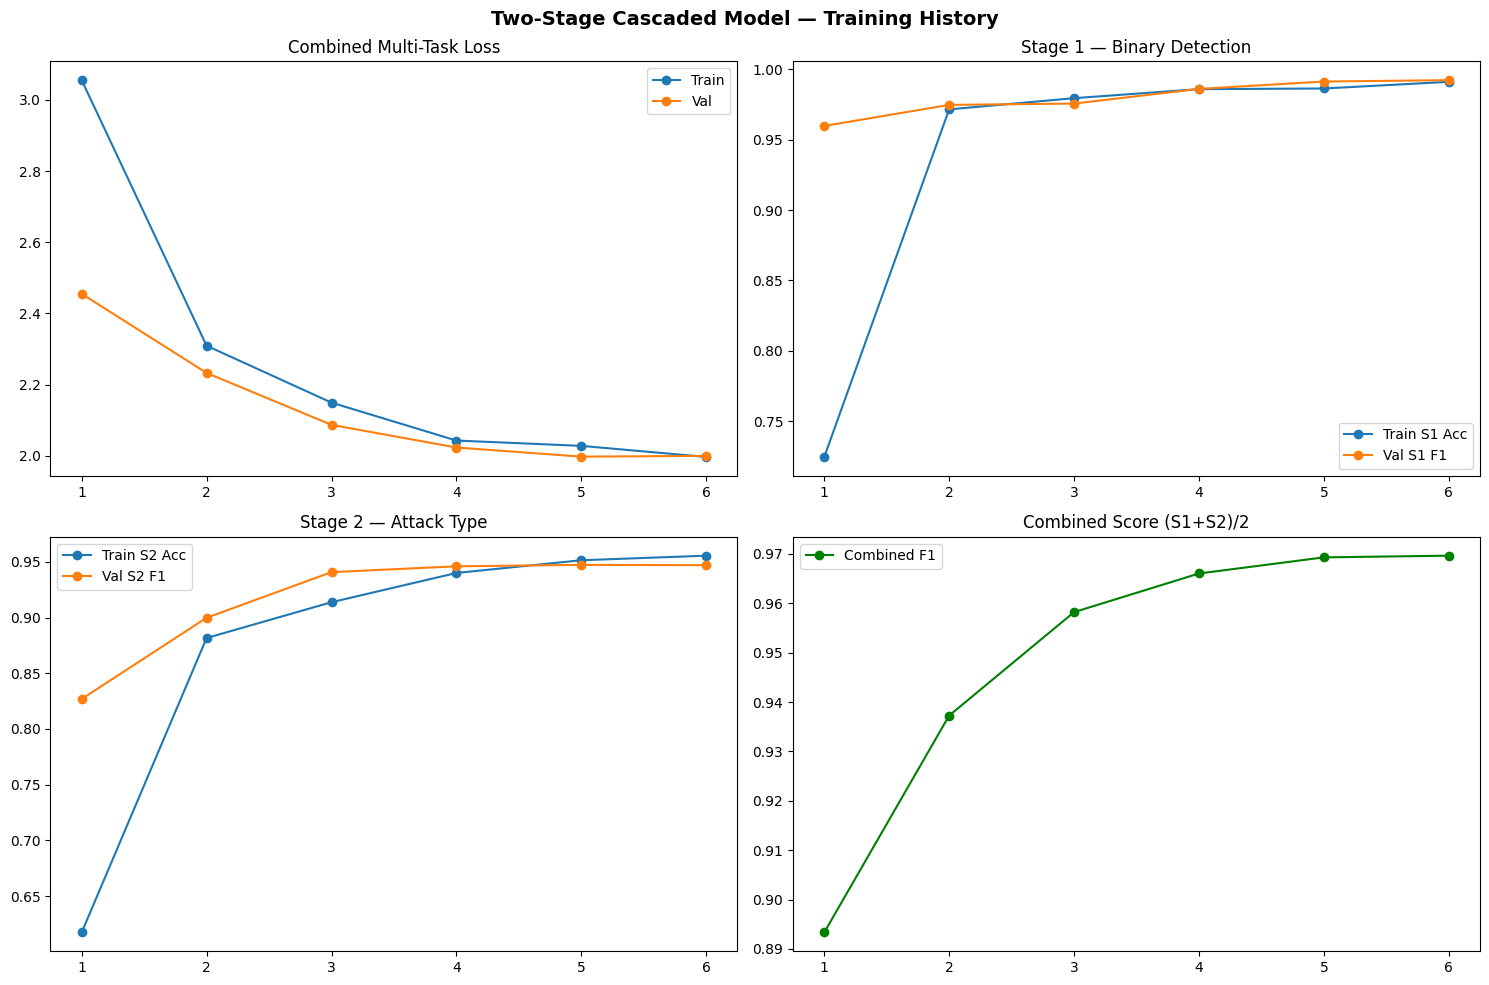

In [ ]:
epochs_r = range(1, len(history)+1)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(epochs_r,[h['loss']     for h in history],'o-',label='Train')
axes[0,0].plot(epochs_r,[h['val_loss'] for h in history],'o-',label='Val')
axes[0,0].set_title('Combined Multi-Task Loss'); axes[0,0].legend()

axes[0,1].plot(epochs_r,[h['s1_acc']     for h in history],'o-',label='Train S1 Acc')
axes[0,1].plot(epochs_r,[h['val_s1_f1']  for h in history],'o-',label='Val S1 F1')
axes[0,1].set_title('Stage 1 — Binary Detection'); axes[0,1].legend()

axes[1,0].plot(epochs_r,[h['s2_acc']     for h in history],'o-',label='Train S2 Acc')
axes[1,0].plot(epochs_r,[h['val_s2_f1']  for h in history],'o-',label='Val S2 F1')
axes[1,0].set_title('Stage 2 — Attack Type'); axes[1,0].legend()

axes[1,1].plot(epochs_r,[(h['val_s1_f1']+h['val_s2_f1'])/2 for h in history],
               'o-', color='green', label='Combined F1')
axes[1,1].set_title('Combined Score (S1+S2)/2'); axes[1,1].legend()

plt.suptitle('Two-Stage Cascaded Model — Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

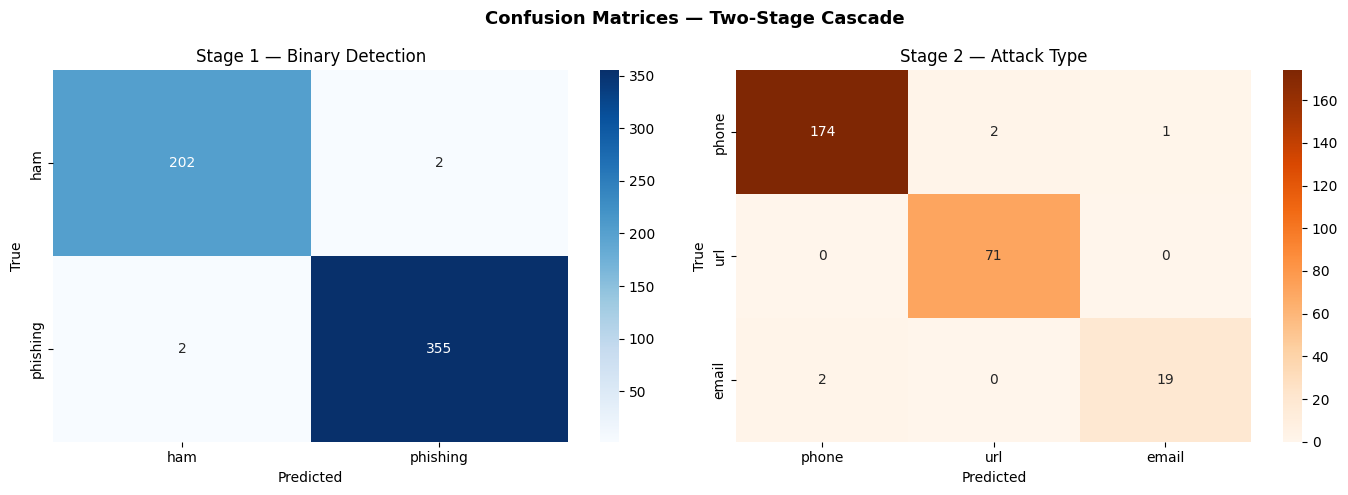

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Stage 1
cm1 = confusion_matrix(te['s1_true'], te['s1_preds'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ham','phishing'], yticklabels=['ham','phishing'])
axes[0].set_title('Stage 1 — Binary Detection', fontsize=12)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
# Stage 2
cm2 = confusion_matrix(te['s2_true'], te['s2_preds'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['phone','url','email'],
            yticklabels=['phone','url','email'])
axes[1].set_title('Stage 2 — Attack Type', fontsize=12)
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Two-Stage Cascade', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
def predict_sms(text: str) -> dict:
    enc = tokenizer(
        text,
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    ids  = enc['input_ids'].to(CONFIG['device'])
    mask = enc['attention_mask'].to(CONFIG['device'])
    model.eval()
    with torch.no_grad():
        s1_logits, s2_logits = model(ids, mask)
    s1_probs = torch.softmax(s1_logits, dim=-1)
    s1_conf, s1_pred = torch.max(s1_probs, dim=-1)

    s1_label = S1_ID2LABEL[int(s1_pred.item())]
    s1_c     = float(s1_conf.item())

    if s1_label == 'ham':
        return {
            'stage1': 'ham',
            's1_confidence': s1_c,
            'stage2': None,
            's2_confidence': None,
            'verdict': 'SAFE — No phishing detected'
        }
    s2_probs = torch.softmax(s2_logits, dim=-1)
    s2_conf, s2_pred = torch.max(s2_probs, dim=-1)

    s2_label = S2_ID2LABEL[int(s2_pred.item())]
    s2_c     = float(s2_conf.item())

    return {
        'stage1': 'phishing',
        's1_confidence': s1_c,
        'stage2': s2_label,
        's2_confidence': s2_c,
        'verdict': f'PHISHING DETECTED — {s2_label.upper().replace("_", " ")}'
    }


# Test messages
test_messages = [
    ('Hey, are you coming to dinner tonight?',
     'ham'),
    ('URGENT: Your bank account is blocked. Call 09012345678 immediately.',
     'phone_phishing'),
    ('Your account has been suspended. Verify now: http://secure-login.xyz/verify',
     'url_phishing'),
    ('Your email will expire in 24h. Reply with password to admin@secure-mail.net',
     'email_phishing'),
    ('Congratulations! You have won £1000. Click http://win-prize.biz/claim to collect.',
     'url_phishing'),
    ('Hi Mum, just landed safely. Will call later!',
     'ham'),
]
print('Predictions')
correct = 0
for text, expected in test_messages:
    result = predict_sms(text)
    predicted = result['stage2'] if result['stage2'] else 'ham'

    match = 'PASS' if predicted == expected else 'FAIL'

    print(f'{match} TEXT     : {text[:65]}')
    print(f'  VERDICT  : {result["verdict"]}')
    print(f'  S1       : {result["stage1"]} ({result["s1_confidence"]:.2%})', end='')

    if result['stage2']:
        print(f'  →  S2: {result["stage2"]} ({result["s2_confidence"]:.2%})', end='')

    print(f'  [expected: {expected}]')
    print()

    if predicted == expected:
        correct += 1

print(f'Demo accuracy: {correct}/{len(test_messages)}')

Predictions
PASS TEXT     : Hey, are you coming to dinner tonight?
  VERDICT  : SAFE — No phishing detected
  S1       : ham (97.37%)  [expected: ham]

PASS TEXT     : URGENT: Your bank account is blocked. Call 09012345678 immediatel
  VERDICT  : PHISHING DETECTED — PHONE PHISHING
  S1       : phishing (90.59%)  →  S2: phone_phishing (70.61%)  [expected: phone_phishing]

PASS TEXT     : Your account has been suspended. Verify now: http://secure-login.
  VERDICT  : PHISHING DETECTED — URL PHISHING
  S1       : phishing (92.04%)  →  S2: url_phishing (88.16%)  [expected: url_phishing]

PASS TEXT     : Your email will expire in 24h. Reply with password to admin@secur
  VERDICT  : PHISHING DETECTED — EMAIL PHISHING
  S1       : phishing (88.33%)  →  S2: email_phishing (98.02%)  [expected: email_phishing]

PASS TEXT     : Congratulations! You have won £1000. Click http://win-prize.biz/c
  VERDICT  : PHISHING DETECTED — URL PHISHING
  S1       : phishing (92.29%)  →  S2: url_phishing (88.09%)

In [ ]:
!pip install onnx onnxruntime -q
!pip install onnx onnxruntime onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 16.1 MB/s eta 0:00:00


In [ ]:

import torch
import onnx
from transformers import DistilBertModel, DistilBertTokenizerFast
import torch.nn as nn

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_PATH = '/content/saved_twostage/best_model.pt'
MODEL_NAME = 'distilbert-base-uncased'

# Rebuild exact model architecture
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states).squeeze(-1)
        scores  = scores.masked_fill(attention_mask == 0, -1e9)
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        return (hidden_states * weights).sum(dim=1)

class TwoStageCascadeModel(nn.Module):
    def __init__(self, model_name, dropout=0.5):
        super().__init__()
        self.backbone    = DistilBertModel.from_pretrained(model_name)
        hidden           = self.backbone.config.hidden_size
        self.dropout     = nn.Dropout(dropout)
        self.pool        = AttentionPooling(hidden)
        self.stage1_head = nn.Sequential(
            nn.Linear(hidden, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.GELU(), nn.Dropout(dropout/2), nn.Linear(64, 2),
        )
        self.stage2_head = nn.Sequential(
            nn.Linear(hidden, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout/2),
            nn.Linear(128, 3),
        )
    def forward(self, input_ids, attention_mask):
        out    = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(out.last_hidden_state, attention_mask)
        cls    = self.dropout(pooled)
        return self.stage1_head(cls), self.stage2_head(cls)

#Load weights
model = TwoStageCascadeModel(MODEL_NAME).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Model loaded from {MODEL_PATH}')

#Export wrapper
class CombinedWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.backbone    = model.backbone
        self.dropout     = model.dropout
        self.pool        = model.pool
        self.stage1_head = model.stage1_head
        self.stage2_head = model.stage2_head

    def forward(self, input_ids, attention_mask):
        out    = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(out.last_hidden_state, attention_mask)
        cls    = self.dropout(pooled)
        return self.stage1_head(cls), self.stage2_head(cls)

dummy_ids  = torch.zeros(1, 128, dtype=torch.long).to(DEVICE)
dummy_mask = torch.ones(1, 128, dtype=torch.long).to(DEVICE)

combined = CombinedWrapper(model).to(DEVICE)
combined.eval()

torch.onnx.export(
    combined, (dummy_ids, dummy_mask),
    "/tmp/smishguard_combined.onnx",
    input_names  = ["input_ids", "attention_mask"],
    output_names = ["stage1_logits", "stage2_logits"],
    dynamic_axes = {"input_ids": {0:"batch"}, "attention_mask": {0:"batch"},
                    "stage1_logits": {0:"batch"}, "stage2_logits": {0:"batch"}},
    opset_version = 18,
    do_constant_folding = True,
)

m = onnx.load("/tmp/smishguard_combined.onnx")
onnx.save_model(m, "smishguard_combined.onnx", save_as_external_data=False)

import os
size = os.path.getsize("smishguard_combined.onnx") / (1024*1024)
print(f" Combined model size: {size:.1f} MB")
print(f"IR version: {m.ir_version}")

# ── Download ───────────────────────────────────────────────────────
from google.colab import files
files.download('smishguard_combined.onnx')
print(' Download started!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded from /content/saved_twostage/best_model.pt


/tmp/ipykernel_2760/988227238.py:72: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `CombinedWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CombinedWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


Applied 42 of general pattern rewrite rules.
 Combined model size: 256.3 MB
IR version: 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download started!
